# 02 – Data Cleaning & Integration
## CIP_FS26_203 | Weather & Electricity Prices in Switzerland

This notebook cleans and integrates the three raw datasets:
- **Open-Meteo** – Weather data (Zurich, Basel, Geneva, Lugano)
- **ENTSO-E** – Day-ahead electricity prices (CH, EUR/MWh)
- **Swissgrid** – National electricity load data (MW)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Display settings ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("All packages loaded successfully!")

All packages loaded successfully!


## 1. ENTSO-E – Day-Ahead Prices Cleaning

### 1.1 Basic inspection of fetched API data

In [14]:
# --- Load raw ENTSO-E prices ---
df_prices = pd.read_csv("../data/raw/prices/entsoe_prices_raw.csv", parse_dates=["date"])

# --- Basic inspection ---
print(f"Shape: {df_prices.shape}")
print(f"\nData types:\n{df_prices.dtypes}")
print(f"\nDate range: {df_prices['date'].min()} to {df_prices['date'].max()}")
print(f"\nMissing values:\n{df_prices.isnull().sum()}")
print(f"\nBasic statistics:\n{df_prices['price_eur_mwh'].describe()}")

# --- Check for missing dates (gaps in time series) ---
full_range = pd.date_range(start=df_prices["date"].min(),
                           end=df_prices["date"].max(),
                           freq="D")
missing_dates = full_range.difference(df_prices["date"])
print(f"Missing dates: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(missing_dates)

Shape: (4017, 2)

Data types:
date             datetime64[us]
price_eur_mwh           float64
dtype: object

Date range: 2015-01-01 00:00:00 to 2025-12-30 00:00:00

Missing values:
date             0
price_eur_mwh    0
dtype: int64

Basic statistics:
count   4017.00
mean      84.79
std       83.82
min      -12.67
25%       37.59
50%       55.09
75%       98.42
max      724.87
Name: price_eur_mwh, dtype: float64
Missing dates: 0


**Inspection findings:**
The ENTSO-E dataset contains 4,017 daily observations from 2015-01-01 to 2025-12-30,
with no missing values in either column. The date column is correctly typed as
datetime64 and the price column as float64. No date gaps were detected, confirming
a complete and continuous daily time series.

### 1.2 Graphical inspection of fetched API data

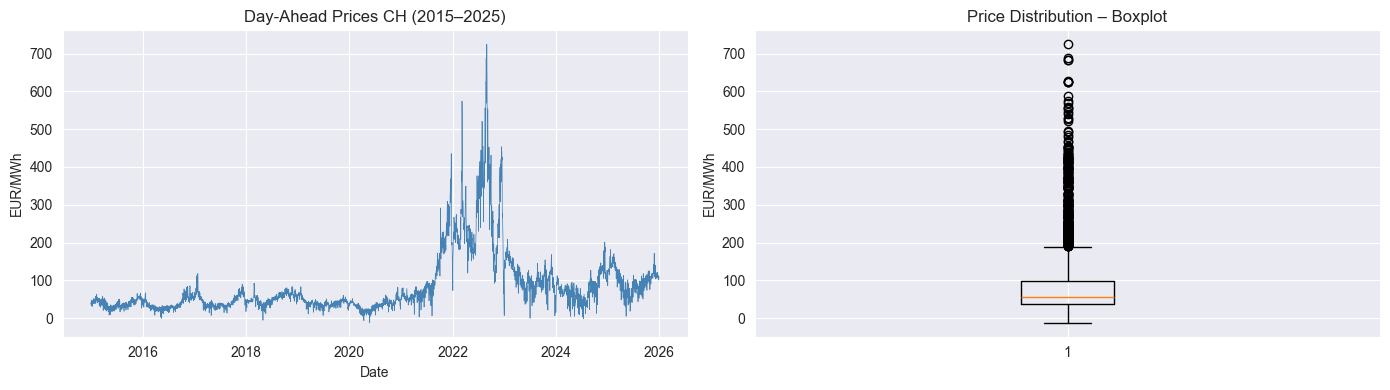

Figure saved.


In [15]:
# --- Visualise price distribution to identify outliers ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
axes[0].plot(df_prices["date"], df_prices["price_eur_mwh"], linewidth=0.5, color="steelblue")
axes[0].set_title("Day-Ahead Prices CH (2015–2025)")
axes[0].set_ylabel("EUR/MWh")
axes[0].set_xlabel("Date")

# Boxplot
axes[1].boxplot(df_prices["price_eur_mwh"].dropna(), vert=True)
axes[1].set_title("Price Distribution – Boxplot")
axes[1].set_ylabel("EUR/MWh")

plt.tight_layout()
plt.savefig("../figures/entsoe_prices_overview.png", dpi=150)
plt.show()
print("Figure saved.")

**Visualisation findings:**
The time series reveals a stable price regime from 2015 to 2020 (mean ~40–60 EUR/MWh),
followed by an extreme spike during the 2021–2023 energy crisis (peak: 724.87 EUR/MWh).
The boxplot confirms a heavily right-skewed distribution with numerous outliers above
the IQR upper bound. A negative minimum (-12.67 EUR/MWh) reflects occasional periods
of excess renewable energy supply. These extreme values are real market events, not
data errors, and will be retained for analysis.

### 1.3 Outlier Analysis of fetched API data

In [16]:
# --- Outlier analysis using IQR method ---
Q1 = df_prices["price_eur_mwh"].quantile(0.25)
Q3 = df_prices["price_eur_mwh"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_prices[
    (df_prices["price_eur_mwh"] < lower) |
    (df_prices["price_eur_mwh"] > upper)
]

print(f"IQR bounds: [{lower:.2f}, {upper:.2f}] EUR/MWh")
print(f"Outliers detected: {len(outliers)} rows ({len(outliers)/len(df_prices)*100:.1f}%)")
print(f"Outlier date range: {outliers['date'].min().date()} to {outliers['date'].max().date()}")
print(f"\nOutlier price statistics:\n{outliers['price_eur_mwh'].describe()}")

IQR bounds: [-53.65, 189.66] EUR/MWh
Outliers detected: 370 rows (9.2%)
Outlier date range: 2021-10-07 to 2024-12-11

Outlier price statistics:
count   370.00
mean    301.89
std     104.97
min     190.13
25%     220.92
50%     265.73
75%     366.70
max     724.87
Name: price_eur_mwh, dtype: float64


**Outlier findings & decision:**
The IQR method (bounds: [-53.65, 189.66] EUR/MWh) identifies 370 rows (9.2%) as
statistical outliers. These observations span from 2021-10-07 to 2024-12-11, with
a mean of 301.89 EUR/MWh and a peak of 724.87 EUR/MWh. This period corresponds
directly to the European energy crisis triggered by post-COVID demand recovery and
the disruption of Russian gas supplies following the outbreak of the Russia-Ukraine
war in February 2022. These are documented real-world market events – not
measurement errors or data quality issues. Removing or capping these values would
distort the analysis of RQ2 and RQ3, as the crisis period represents the most
informative signal for understanding the relationship between weather conditions
and electricity prices under stress. Outliers are therefore retained in full. **Decision -> Retain outliers.**

### 1.4 Data Type & Range Validation

In [17]:
# --- Validate data types ---
assert df_prices["date"].dtype == "datetime64[us]", "ERROR: date column is not datetime"
assert df_prices["price_eur_mwh"].dtype == "float64", "ERROR: price column is not float64"
print("Data types: OK")

# --- Validate value ranges ---
# Prices below -500 EUR/MWh or above 5000 EUR/MWh are physically implausible
price_min_threshold = -500
price_max_threshold = 5000

invalid_range = df_prices[
    (df_prices["price_eur_mwh"] < price_min_threshold) |
    (df_prices["price_eur_mwh"] > price_max_threshold)
]
print(f"Values outside plausible range [{price_min_threshold}, {price_max_threshold}]: {len(invalid_range)} rows")

# --- Validate date range ---
assert df_prices["date"].min() == pd.Timestamp("2015-01-01"), "ERROR: Start date mismatch"
assert df_prices["date"].max() >= pd.Timestamp("2025-12-30"), "ERROR: End date mismatch"
print("Date range: OK")

print("\nAll validation checks passed.")

Data types: OK
Values outside plausible range [-500, 5000]: 0 rows
Date range: OK

All validation checks passed.


**Validation findings:**
All data type and range checks passed without errors. The date column is correctly
typed as datetime64 and the price column as float64. No physically implausible
price values were detected outside the threshold of [-500, 5000] EUR/MWh. The
dataset covers the full intended period from 2015-01-01 to 2025-12-30.

### 1.5 Save Cleaned ENTSO-E Data

In [18]:
# --- Save cleaned ENTSO-E prices to processed folder ---
output_path = "../data/processed/entsoe_prices_clean.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_prices_clean = df_prices.copy()
df_prices_clean.to_csv(output_path, index=False)
print(f"Saved: {output_path} ({len(df_prices_clean)} rows, {df_prices_clean.shape[1]} columns)")

Saved: ../data/processed/entsoe_prices_clean.csv (4017 rows, 2 columns)


**Summary – ENTSO-E Cleaning:**
The ENTSO-E dataset required minimal cleaning: no missing values, no date gaps,
and correct data types were confirmed. 370 statistical outliers (9.2%) corresponding
to the 2021–2023 energy crisis were identified and deliberately retained. The cleaned
dataset (4,017 rows) has been saved to `data/processed/entsoe_prices_clean.csv`
and is ready for integration with the weather and load datasets.

## 2. Open-Meteo – Weather Data Cleaning (Zurich, Basel, Geneva, Lugano)

### 2.1 Basic Inspection

In [19]:
import pandas as pd
import numpy as np

# load data
df = pd.read_csv('../data/raw/weather/weather_raw.csv')

# first overview
print(df.shape)
print(df.dtypes)
df.head()

(16072, 10)
temperature_2m_mean        float64
temperature_2m_max         float64
temperature_2m_min         float64
precipitation_sum          float64
windspeed_10m_max          float64
shortwave_radiation_sum    float64
cloudcover_mean              int64
sunshine_duration          float64
date                           str
city                           str
dtype: object


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,date,city
0,4.00,7.10,0.10,0.00,6.30,6.18,7,30686.13,2015-01-01,Zurich
1,6.40,11.90,0.80,0.00,10.50,5.95,71,25552.94,2015-01-02,Zurich
2,9.40,12.70,7.50,0.00,12.30,5.50,56,28179.38,2015-01-03,Zurich
3,7.60,12.10,2.70,0.00,13.00,6.24,13,30869.75,2015-01-04,Zurich
4,6.70,10.30,2.20,0.00,12.20,6.63,6,30941.12,2015-01-05,Zurich


**Basic inspection findings:**
The Open-Meteo dataset contains 16,072 daily observations across four Swiss cities (Zurich, Basel, Geneva, Lugano) covering 2015-01-01 to 2025-12-31. This corresponds to 4 cities × ~4,018 days, which is consistent with the expected coverage. The dataset has 10 columns: 8 numeric weather variables and 2 categorical columns (date as string, city as string). No structural anomalies were detected.

### 2.2 Missing Value Check

In [20]:
#looking out for missing values

print(df.isnull().sum())

temperature_2m_mean        0
temperature_2m_max         0
temperature_2m_min         0
precipitation_sum          0
windspeed_10m_max          0
shortwave_radiation_sum    0
cloudcover_mean            0
sunshine_duration          0
date                       0
city                       0
dtype: int64


**Missing value findings:**
No missing values were detected across all 10 columns. The dataset is complete and requires no imputation.

### 2.3 Data Type Correction


In [21]:
# correcting data types

df['date'] = pd.to_datetime(df['date'])
print(df.dtypes)

temperature_2m_mean               float64
temperature_2m_max                float64
temperature_2m_min                float64
precipitation_sum                 float64
windspeed_10m_max                 float64
shortwave_radiation_sum           float64
cloudcover_mean                     int64
sunshine_duration                 float64
date                       datetime64[us]
city                                  str
dtype: object


**Data type findings:**
The `date` column was stored as a plain string (object) and has been successfully converted to `datetime64[us]`. This conversion is necessary to enable date-based operations such as month extraction (used for season assignment), chronological sorting, and gap detection. All numeric weather variables are correctly typed as `float64`, which is appropriate as measurements like temperature (e.g. 13.4°C) or precipitation (e.g. 0.2 mm) contain decimal values. The exception is `cloudcover_mean`, which is typed as `int64` – this is correct since cloud cover is reported in whole percentages (0–100) with no meaningful decimal places.

### 2.4 Statistical Summary

In [22]:
df.describe()

,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,date
count,16072.00,16072.00,16072.00,16072.00,16072.00,16072.00,16072.00,16072.00,16072
mean,13.73,17.74,9.74,4.90,8.00,13.36,55.81,31967.10,2020-07-01 12:00:00
min,-3.20,-0.20,-10.20,0.00,1.80,0.41,0.00,0.00,2015-01-01 00:00:00
25%,7.40,11.50,3.60,0.00,6.10,6.62,31.00,24372.99,2017-10-01 00:00:00
50%,13.40,17.40,9.50,0.20,7.40,12.44,56.00,34225.40,2020-07-01 12:00:00
75%,19.90,23.80,15.80,3.90,9.20,20.25,83.00,45272.20,2023-04-02 00:00:00
max,30.10,36.00,25.10,128.60,26.30,30.28,100.00,54000.00,2025-12-31 00:00:00
std,7.13,7.48,6.89,11.59,2.86,7.78,30.07,15935.10,NaN


**Statistical summary findings:**
The descriptive statistics confirm realistic value ranges for Switzerland. Mean temperature across all cities and years is 13.7°C, with daily means ranging from -3.2°C to 30.1°C. Maximum daily precipitation reaches 128.6 mm, consistent with extreme but plausible Alpine events. Wind speeds range from 1.8 to 26.3 km/h, and solar radiation values are bounded between 0.41 and 30.28 MJ/m². Cloud cover spans the full 0–100% range. No implausible summary statistics detected.

### 2.5 Outlier Analysis

In [23]:
# Temperatures outside the range of -30 to 45 degrees?
print(df[df['temperature_2m_mean'] < -30])
print(df[df['temperature_2m_mean'] > 45])

# Negative precipitation values?
print(df[df['precipitation_sum'] < 0])

Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []


In [24]:
# Wind speed: negative or unrealistically high (>150 km/h)?
print("wind speed < 0:")
print(df[df['windspeed_10m_max'] < 0])
print("windspeed > 150:")
print(df[df['windspeed_10m_max'] > 150])

# Solar radiation: negative?
print("solar_radiation < 0:")
print(df[df['shortwave_radiation_sum'] < 0])

# Cloud cover: must be between 0 and 100%
print("cloud_cover < 0:")
print(df[df['cloudcover_mean'] < 0])
print("cloud_cover > 100:")
print(df[df['cloudcover_mean'] > 100])

# Sunshine duration: negative?
print("sunshine_duration < 0:")
print(df[df['sunshine_duration'] < 0])

wind speed < 0:
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []
windspeed > 150:
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []
solar_radiation < 0:
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []
cloud_cover < 0:
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature_2m_min, precipitation_sum, windspeed_10m_max, shortwave_radiation_sum, cloudcover_mean, sunshine_duration, date, city]
Index: []
cloud_cover > 100:
Empty DataFrame
Columns: [temperature_2m_mean, temperature_2m_max, temperature

**Outlier findings & decision:**
Physical plausibility checks were performed on all weather variables to detect potential data errors or API retrieval issues. Each variable was tested against domain-specific thresholds: temperatures against the absolute extremes ever recorded in Switzerland ([-30°C, 45°C]), precipitation and radiation for non-negative values (physically impossible otherwise), wind speeds against a generous upper bound of 150 km/h, and cloud cover for the valid [0, 100%] range. All checks passed with zero violations: temperatures are within the range [-30°C, 45°C], precipitation is non-negative, wind speeds are within [0, 150 km/h], solar radiation and sunshine duration are non-negative, and cloud cover is within the valid [0, 100%] range. The dataset contains no outliers requiring removal or correction. **Decision → No outlier treatment needed.**

### 2.6 Feature Engineering – Season Column

In [25]:
# Add season as a new column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['date'].dt.month.apply(get_season)
print(df[['date', 'season']].head(10))

        date  season
0 2015-01-01  Winter
1 2015-01-02  Winter
2 2015-01-03  Winter
3 2015-01-04  Winter
4 2015-01-05  Winter
5 2015-01-06  Winter
6 2015-01-07  Winter
7 2015-01-08  Winter
8 2015-01-09  Winter
9 2015-01-10  Winter


In [26]:
# Verify that seasons are correctly assigned
print(df.groupby('season')['date'].agg(['min', 'max', 'count']))

              min        max  count
season                             
Autumn 2015-09-01 2025-11-30   4004
Spring 2015-03-01 2025-05-31   4048
Summer 2015-06-01 2025-08-31   4048
Winter 2015-01-01 2025-12-31   3972


**Season assignment findings:**
The `season` column was derived from the month of each observation using meteorological season boundaries (Winter: Dec–Feb, Spring: Mar–May, Summer: Jun–Aug, Autumn: Sep–Nov). The groupby verification confirms correct assignment: Autumn spans Sep–Nov, Spring Mar–May, Summer Jun–Aug, and Winter Jan–Feb / Dec. Row counts are balanced across seasons (~4,000 per season), consistent with 11 years of data across 4 cities. Winter has slightly fewer rows (3,972) due to February being the shortest month.

### 2.7 Save Cleaned Weather Data

In [41]:
df.to_csv('../data/processed/weather_clean.csv', index=False)
print(f"safed: {df.shape[0]} rows, {df.shape[1]} columns")

safed: 35041 rows, 65 columns


**Summary – Open-Meteo Weather Cleaning:**
The Open-Meteo dataset required minimal cleaning: no missing values, no physical outliers, and only a single data type correction (date column from string to datetime64). A new `season` column was engineered from the date to support seasonal analysis in RQ1 and RQ2. The cleaned dataset (16,072 rows, 11 columns) has been saved to `data/processed/weather_clean.csv` and is ready for integration with the ENTSO-E and Swissgrid datasets.

## 2.8 Open-Meteo – Apparent Temperature Cleaning & Merge

### 2.8.1 Basic Inspection

In [28]:
# --- Load raw apparent temperature data ---
df_app = pd.read_csv('../data/raw/weather/apparent_temp_raw.csv')

# --- Basic overview: shape, dtypes, first rows ---
print(df_app.shape)
print(df_app.dtypes)
df_app.head()


(16072, 5)
apparent_temperature_mean    float64
apparent_temperature_max     float64
apparent_temperature_min     float64
date                             str
city                             str
dtype: object


,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,date,city
0,-5.70,-0.90,-10.30,2015-01-01,Zurich
1,-3.20,1.10,-8.20,2015-01-02,Zurich
2,1.10,4.90,-1.30,2015-01-03,Zurich
3,0.40,4.50,-1.80,2015-01-04,Zurich
4,-0.80,2.30,-3.30,2015-01-05,Zurich


**Basic inspection findings:**
The apparent temperature dataset contains 16,072 daily observations across four Swiss cities (Zurich, Basel, Geneva, Lugano) covering 2015-01-01 to 2025-12-31. This matches exactly the shape of the existing weather dataset (16,072 rows), confirming consistent coverage. The dataset has 5 columns: three apparent temperature variables (mean, max, min) as float64, and the date and city columns.

### 2.8.2 Missing Value Check

In [29]:
# --- Check for missing values across all columns ---
print(df_app.isnull().sum())

apparent_temperature_mean    0
apparent_temperature_max     0
apparent_temperature_min     0
date                         0
city                         0
dtype: int64


**Missing value findings:**
No missing values were detected across all 5 columns. The dataset is complete and requires no imputation.

### 2.8.3 Data Type Correction

In [30]:
# --- Convert date column from string to datetime ---
df_app['date'] = pd.to_datetime(df_app['date'])
print(df_app.dtypes)

apparent_temperature_mean           float64
apparent_temperature_max            float64
apparent_temperature_min            float64
date                         datetime64[us]
city                                    str
dtype: object


**Data type findings:**
The `date` column was stored as a plain string (object) and has been successfully converted to `datetime64[us]`. This is necessary for the subsequent merge with the existing weather dataset on the date and city columns. All three apparent temperature variables remain correctly typed as `float64`.

### 2.8.4 Statistical Summary

In [31]:
# --- Statistical summary of apparent temperature variables ---
df_app.describe()

,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,date
count,16072.00,16072.00,16072.00,16072
mean,10.60,15.10,6.15,2020-07-01 12:00:00
min,-14.70,-13.00,-20.60,2015-01-01 00:00:00
25%,3.00,6.90,-1.00,2017-10-01 00:00:00
50%,9.80,14.40,5.30,2020-07-01 12:00:00
75%,18.10,23.00,13.20,2023-04-02 00:00:00
max,33.40,41.50,29.10,2025-12-31 00:00:00
std,9.20,10.01,8.58,NaN


**Statistical summary findings:**
The descriptive statistics confirm realistic value ranges for apparent temperature in Switzerland. The mean apparent temperature across all cities and years is 10.60°C, which is slightly lower than the actual mean temperature (13.7°C), reflecting the cooling effect of wind chill. Daily mean apparent temperatures range from -14.70°C to 33.40°C, while the maximum apparent temperature reaches 41.50°C and the minimum drops to -20.60°C. All values fall well within the defined plausibility thresholds of [-50°C, 55°C]. No implausible summary statistics detected.

### 2.8.5 Outlier Analysis

In [32]:
# --- Check for physically implausible apparent temperature values ---
# Apparent temperature can be lower than actual temperature due to wind chill
# Thresholds: -50°C (extreme cold) to 55°C (extreme heat index)
print("Apparent temperature mean < -50:")
print(df_app[df_app['apparent_temperature_mean'] < -50])

print("Apparent temperature mean > 55:")
print(df_app[df_app['apparent_temperature_mean'] > 55])

# --- Check for missing date/city combinations ---
print(f"\nUnique cities: {df_app['city'].unique()}")
print(f"Date range: {df_app['date'].min()} to {df_app['date'].max()}")

Apparent temperature mean < -50:
Empty DataFrame
Columns: [apparent_temperature_mean, apparent_temperature_max, apparent_temperature_min, date, city]
Index: []
Apparent temperature mean > 55:
Empty DataFrame
Columns: [apparent_temperature_mean, apparent_temperature_max, apparent_temperature_min, date, city]
Index: []

Unique cities: <StringArray>
['Zurich', 'Basel', 'Geneva', 'Lugano']
Length: 4, dtype: str
Date range: 2015-01-01 00:00:00 to 2025-12-31 00:00:00


**Outlier findings & decision:**
Physical plausibility checks were performed using wider thresholds than for the actual temperature variable. While actual temperatures in Switzerland are bounded by [-30°C, 45°C], apparent temperature requires a broader range of [-50°C, 55°C] to account for two additional physical effects: wind chill, which can make temperatures feel significantly colder than the actual air temperature (e.g. -15°C air temperature combined with strong wind can result in a perceived temperature of around -30°C), and the heat index, which can make high humidity conditions feel considerably warmer than the actual temperature. All checks passed with zero violations across all three apparent temperature variables. **Decision → No outlier treatment needed.**

### 2.8.6 Graphical Inspection

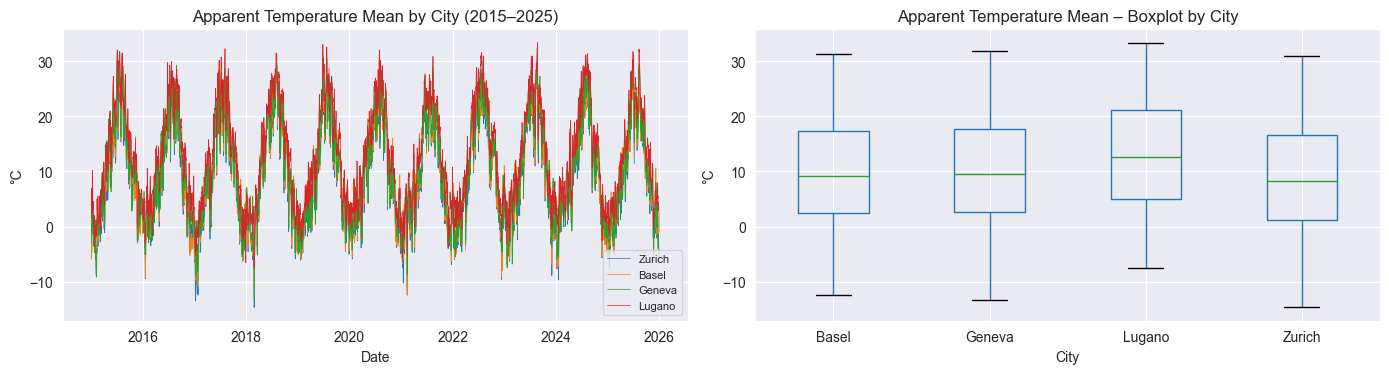

Figure saved.


In [33]:


# --- Plot apparent temperature mean over time for each city ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
for city in df_app['city'].unique():
    df_city = df_app[df_app['city'] == city]
    axes[0].plot(df_city['date'], df_city['apparent_temperature_mean'],
                 linewidth=0.5, label=city)
axes[0].set_title("Apparent Temperature Mean by City (2015–2025)")
axes[0].set_ylabel("°C")
axes[0].set_xlabel("Date")
axes[0].legend(fontsize=8)

# Boxplot per city
df_app.boxplot(column='apparent_temperature_mean', by='city', ax=axes[1])
axes[1].set_title("Apparent Temperature Mean – Boxplot by City")
axes[1].set_ylabel("°C")
axes[1].set_xlabel("City")

plt.suptitle("")
plt.tight_layout()
plt.savefig("../figures/apparent_temp_overview.png", dpi=150)
plt.show()
print("Figure saved.")

**Graphical inspection findings:**
The time series confirms a clear seasonal pattern across all four cities, with apparent temperatures ranging from around -15°C in winter to over 30°C in summer. The seasonal cycle is consistent across all 11 years with no visible anomalies or sudden jumps. The boxplot reveals regional differences: Lugano shows the highest median apparent temperature, consistent with its location south of the Alps, while Zurich and Basel show similar distributions. Geneva sits in between. All four cities show comparable spread and no extreme outliers are visible. The data quality is confirmed as good.

### 2.8.7 Merge with Existing Weather Dataset

In [34]:
# --- Load the existing cleaned weather dataset ---
df_weather = pd.read_csv('../data/processed/weather_clean.csv', parse_dates=['date'])

# --- Merge apparent temperature into weather dataset on date and city ---
df_weather_merged = df_weather.merge(
    df_app[['date', 'city', 'apparent_temperature_mean',
            'apparent_temperature_max', 'apparent_temperature_min']],
    on=['date', 'city'],
    how='left'
)

# --- Verify shape and check for missing values after merge ---
print(f"Shape before merge: {df_weather.shape}")
print(f"Shape after merge:  {df_weather_merged.shape}")
print(f"\nMissing values after merge:")
print(df_weather_merged[['apparent_temperature_mean',
                          'apparent_temperature_max',
                          'apparent_temperature_min']].isnull().sum())

df_weather_merged.head()

Shape before merge: (16072, 11)
Shape after merge:  (16072, 14)

Missing values after merge:
apparent_temperature_mean    0
apparent_temperature_max     0
apparent_temperature_min     0
dtype: int64


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,date,city,season,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min
0,4.00,7.10,0.10,0.00,6.30,6.18,7,30686.13,2015-01-01,Zurich,Winter,-5.70,-0.90,-10.30
1,6.40,11.90,0.80,0.00,10.50,5.95,71,25552.94,2015-01-02,Zurich,Winter,-3.20,1.10,-8.20
2,9.40,12.70,7.50,0.00,12.30,5.50,56,28179.38,2015-01-03,Zurich,Winter,1.10,4.90,-1.30
3,7.60,12.10,2.70,0.00,13.00,6.24,13,30869.75,2015-01-04,Zurich,Winter,0.40,4.50,-1.80
4,6.70,10.30,2.20,0.00,12.20,6.63,6,30941.12,2015-01-05,Zurich,Winter,-0.80,2.30,-3.30


In [35]:
# --- Spot check: compare a few rows manually ---
# apparent temperature should always be <= actual temperature (wind chill effect)
check = df_weather_merged[['date', 'city', 'temperature_2m_mean', 'apparent_temperature_mean']].head(10)
print(check)

# --- Sanity check: apparent_temperature_mean should generally be <= temperature_2m_mean ---
n_violations = (df_weather_merged['apparent_temperature_mean'] >
                df_weather_merged['temperature_2m_mean']).sum()
print(f"\nRows where apparent > actual temperature: {n_violations} ({n_violations/len(df_weather_merged)*100:.1f}%)")
print("(Some violations are expected in summer due to humidity/heat index)")

        date    city  temperature_2m_mean  apparent_temperature_mean
0 2015-01-01  Zurich                 4.00                      -5.70
1 2015-01-02  Zurich                 6.40                      -3.20
2 2015-01-03  Zurich                 9.40                       1.10
3 2015-01-04  Zurich                 7.60                       0.40
4 2015-01-05  Zurich                 6.70                      -0.80
5 2015-01-06  Zurich                 7.70                      -0.20
6 2015-01-07  Zurich                 5.00                      -1.50
7 2015-01-08  Zurich                 6.40                       0.00
8 2015-01-09  Zurich                 8.90                       2.50
9 2015-01-10  Zurich                12.10                       7.30

Rows where apparent > actual temperature: 2650 (16.5%)
(Some violations are expected in summer due to humidity/heat index)


**Merge findings:**
The apparent temperature variables were successfully merged into the existing weather dataset using a left join on `date` and `city`. The shape increased from 16,072 × 11 to 16,072 × 14, confirming that all three apparent temperature variables (mean, max, min) were added correctly. No missing values were introduced by the merge. The spot check confirms plausible values: in winter, apparent temperature is significantly lower than actual temperature due to wind chill. In 16.5% of rows, apparent temperature exceeds actual temperature, which is expected during summer months when high humidity creates a heat index effect. The merge is confirmed as correct.

### 2.8.8 Save Merged Weather Dataset

In [36]:
# --- Overwrite weather_clean.csv with the merged dataset ---
df_weather_merged.to_csv('../data/processed/weather_clean.csv', index=False)
print(f"Saved: {df_weather_merged.shape[0]} rows, {df_weather_merged.shape[1]} columns")
print(f"Columns: {list(df_weather_merged.columns)}")

Saved: 16072 rows, 14 columns
Columns: ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'windspeed_10m_max', 'shortwave_radiation_sum', 'cloudcover_mean', 'sunshine_duration', 'date', 'city', 'season', 'apparent_temperature_mean', 'apparent_temperature_max', 'apparent_temperature_min']


**Summary – Apparent Temperature Cleaning & Merge:**
The apparent temperature dataset required minimal cleaning: no missing values, no physical outliers, and only a single data type correction (date column from string to datetime64). A graphical inspection confirmed clear seasonal patterns and plausible regional differences across all four cities. The three apparent temperature variables (mean, max, min) were successfully merged into the existing `weather_clean.csv` using a left join on date and city. The final dataset now contains 16,072 rows and 14 columns and is ready for use in the statistical analysis.

## 3. Swissgrid – National Load Data Cleaning (CH)

### 3.1 Load and inspect all yearly Excel files

In this step, all yearly Swissgrid Excel files are loaded from the `data/raw/load/` folder and inspected structurally before cleaning. Since Swissgrid data is provided as one Excel file per year, the first priority is to understand whether the files are consistent in terms of sheet names, header structure, column names, and data layout.

This inspection is important because yearly Excel exports often differ slightly across time, for example in:
- sheet names
- additional title or metadata rows
- column naming conventions
- date/time formatting
- inclusion of notes or empty rows

The goal of this step is therefore not yet to clean the data, but to identify the correct import settings and detect possible structural inconsistencies across years.

In [37]:
# 3.1 Load and inspect all yearly Excel files

from pathlib import Path
import pandas as pd

# Folder containing the yearly Swissgrid Excel files
load_folder = Path("../data/raw/load")

# Get all Excel files
excel_files = sorted(load_folder.glob("*.xls*"))

print(f"Number of Swissgrid files found: {len(excel_files)}\n")
for file in excel_files:
    print(file.name)

Number of Swissgrid files found: 11

swissgrid_load_2015.xls
swissgrid_load_2016.xls
swissgrid_load_2017.xls
swissgrid_load_2018.xls
swissgrid_load_2019.xls
swissgrid_load_2020.xlsx
swissgrid_load_2021.xlsx
swissgrid_load_2022.xlsx
swissgrid_load_2023.xlsx
swissgrid_load_2024.xlsx
swissgrid_load_2025.xlsx


In [39]:
# Inspect sheet names of each Excel file

sheet_overview = []

for file in excel_files:
    xls = pd.ExcelFile(file)
    sheet_overview.append({
        "file_name": file.name,
        "sheet_names": xls.sheet_names
    })

sheet_overview_df = pd.DataFrame(sheet_overview)
sheet_overview_df

,file_name,sheet_names
0,swissgrid_load_2015.xls,"[Einstellungen, Uebersicht, Zeitreihen0h15, Ze..."
1,swissgrid_load_2016.xls,"[Einstellungen, Uebersicht, Zeitreihen0h15, Ze..."
2,swissgrid_load_2017.xls,"[Einstellungen, Uebersicht, Zeitreihen0h15, Ze..."
3,swissgrid_load_2018.xls,"[Einstellungen, Uebersicht, Zeitreihen0h15, Ze..."
4,swissgrid_load_2019.xls,"[Einstellungen, Uebersicht, Zeitreihen0h15, Ze..."
5,swissgrid_load_2020.xlsx,"[Einstellungen, Uebersicht, Zeitreihen0h15, Ze..."
6,swissgrid_load_2021.xlsx,"[Einstellungen, Datetime, Uebersicht, Zeitreih..."
7,swissgrid_load_2022.xlsx,"[Einstellungen, Datetime, Uebersicht, Zeitreih..."
8,swissgrid_load_2023.xlsx,"[Einstellungen, Datetime, Uebersicht, Zeitreih..."
9,swissgrid_load_2024.xlsx,"[Einstellungen, Datetime, Uebersicht, Zeitreih..."


In [9]:
# Preview the first few rows of each file (of the sheet Zeitreihe 0:15, since from 2021 there is one more sheet in the file I have to search for the specific Sheetname)
preview_dict = {}

for file in excel_files:
    df_preview = pd.read_excel(file, sheet_name="Zeitreihen0h15", nrows=10)
    preview_dict[file.name] = df_preview

# Show previews one by one
for file_name, preview_df in preview_dict.items():
    print("=" * 100)
    print(f"FILE: {file_name}")
    print("=" * 100)
    display(preview_df)

FILE: swissgrid_load_2015.xls


,Unnamed: 0,Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock,Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock,Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock,Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid,Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid,Positive Sekundär-Regelenergie\nPositive secundary control energy,Negative Sekundär-Regelenergie\nNegative secundary control energy,Positive Tertiär-Regelenergie\nPositive tertiary control energy,Negative Tertiär-Regelenergie\nNegative tertiary control energy,...,"Produktion Kantone OW, NW, UR\nProduction Cantons OW, NW, UR","Verbrauch Kantone OW, NW, UR\nConsumption Cantons OW, NW, UR","Produktion Kantone GE, VD\nProduction Cantons GE, VD","Verbrauch Kantone GE, VD\nConsumption Cantons GE, VD","Produktion Kantone SH, ZH\nProduction Cantons SH, ZH","Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH",Produktion Kantonsübergreifend\nProduction across Cantons,Verbrauch Kantonsübergreifend\nConsumption across Cantons,Produktion Regelzone CH - Ausländische Gebiete\nProduction control area CH - foreign territories,Verbrauch Regelzone CH - Ausländische Gebiete\nConsumption control area CH - foreign territories
0,Zeitstempel,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh
1,2015-01-01 00:15:00,1790683.264,1697771.888,1922526.092,177077.893,1362135.367,37500,0,0,0,...,8730.862,35483.442,26248.344,203085.875,21630.758,271428.077,63184.653,79607.162,547.372,13057.831
2,2015-01-01 00:30:00,1777125.512,1686388.388,1907137.941,172626.54,1353115.668,22200,0,0,0,...,8199.245,34859.735,26345.301,199200.393,21669.423,268050.733,62903.913,77654.465,724.646,13074.058
3,2015-01-01 00:45:00,1807975.847,1724776.569,1940146.345,165918.101,1386782.732,36100,0,0,0,...,8182.595,35091.545,26552.398,196181.841,21864.86,289810.311,63002.367,79637.542,812.006,12685.867
4,2015-01-01 01:00:00,1784943.849,1690007.354,1918599.488,178952.581,1361072.087,16400,0,0,0,...,8014.491,34221.951,26642.845,192456.63,21688.068,287030.564,62824.629,79547.734,730.762,12395.146
5,2015-01-01 01:15:00,1813997.328,1681642.276,1954829.767,215535.087,1348747.31,52700,0,0,0,...,7835.558,35102.739,26931.63,189696.512,21911.78,287332.571,62972.646,76718.83,560.748,12527.151
6,2015-01-01 01:30:00,1794654.179,1653067.671,1933012.13,224251.768,1327489.918,37600,0,0,0,...,8696.617,34555.578,27004.834,186838.943,22040.32,282347.374,62590.056,75574.444,614.234,12310.696
7,2015-01-01 01:45:00,1792982.615,1649713.579,1931314.936,224389.177,1329587.2,18800,0,15000,0,...,7511.335,34345.765,27086.491,184070.828,21993.395,292517.551,62495.888,75049.719,638.216,12023.079
8,2015-01-01 02:00:00,1759937.523,1613997.873,1890461.336,227292.953,1298708.826,900,0,15000,0,...,8799.488,33530.469,26883.498,181218.513,22114.357,287479.028,62648.2,68791.84,592.634,11906.001
9,2015-01-01 02:15:00,1773264.06,1634542.061,1903412.649,219651.79,1312768.338,41500,0,15000,0,...,18504.586,34075.996,24527.85,178888.67,21898.091,287693.9,62682.365,64861.431,578.483,11685.306


FILE: swissgrid_load_2016.xls


,Unnamed: 0,Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock,Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock,Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock,Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid,Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid,Positive Sekundär-Regelenergie\nPositive secundary control energy,Negative Sekundär-Regelenergie\nNegative secundary control energy,Positive Tertiär-Regelenergie\nPositive tertiary control energy,Negative Tertiär-Regelenergie\nNegative tertiary control energy,...,"Produktion Kantone OW, NW, UR\nProduction Cantons OW, NW, UR","Verbrauch Kantone OW, NW, UR\nConsumption Cantons OW, NW, UR","Produktion Kantone GE, VD\nProduction Cantons GE, VD","Verbrauch Kantone GE, VD\nConsumption Cantons GE, VD","Produktion Kantone SH, ZH\nProduction Cantons SH, ZH","Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH",Produktion Kantonsübergreifend\nProduction across Cantons,Verbrauch Kantonsübergreifend\nConsumption across Cantons,Produktion Regelzone CH - Ausländische Gebiete\nProduction control area CH - foreign territories,Verbrauch Regelzone CH - Ausländische Gebiete\nConsumption control area CH - foreign territories
0,Zeitstempel,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh
1,2016-01-01 00:15:00,1525210.59,1164381.464,1707694.263,504534.221523,904057.587,0,-28000,0,0,...,4036.253,29917.023,19524.702,205493.228,20614.084,238553.962,39869.182,61162.5,602.172,13044.391
2,2016-01-01 00:30:00,1507491.133,1173541.446,1682773.05,468540.308417,910321.221,0,-5000,0,0,...,4006.097,29566.128,19692.943,194984.469,21002.237,234306.744,39659.573,60323.153,587.921,12983.643
3,2016-01-01 00:45:00,1539664.783,1195994.738,1717866.705,478188.190464,930864.415,100,-100,0,0,...,3690.93,29590.031,19247.493,191376.519,21177.539,257059.591,39617.019,63168.531,574.743,12618.372
4,2016-01-01 01:00:00,1518853.125,1185615.942,1696938.234,471684.571407,921722.637,100,-400,0,0,...,3541.732,28738.802,19374.521,191108.696,21129.91,255021.802,39667.306,63335.079,536.888,12146.595
5,2016-01-01 01:15:00,1539265.905,1199010.473,1744748.515,505271.904584,932517.96,0,-2300,0,0,...,3946.784,30369.154,19247.993,212210.37,21197.812,253264.89,39811.108,50897.187,576.201,12342.304
6,2016-01-01 01:30:00,1519988.74,1188289.432,1727342.337,502477.673504,928700.88,0,-4600,0,0,...,3840.641,29759.071,19241.009,214337.985,21175.802,247620.558,39676.607,45519.084,571.998,12027.912
7,2016-01-01 01:45:00,1515704.746,1187957.544,1741496.252,516245.798361,933361.58,0,-5600,0,-14750,...,3445.567,29455.337,19043.796,211551.797,20961.84,257442.474,39524.834,45440.782,558.279,11793.235
8,2016-01-01 02:00:00,1484500.718,1152866.748,1712413.729,521751.990629,905594.62,0,-21800,0,-14750,...,3222.071,28355.381,19282.022,209676.449,20937.804,252036.059,39510.951,48199.228,560.28,11661.089
9,2016-01-01 02:15:00,1500466.532,1171004.144,1791066.086,575434.743784,910167,500,0,0,-14750,...,2839.707,28484.817,20989.199,207122.175,21258.744,250629.856,39307.462,50203.67,568.469,11572.836


FILE: swissgrid_load_2017.xls


...

,Unnamed: 0,Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock,Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock,Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock,Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid,Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid,Positive Sekundär-Regelenergie\nPositive secundary control energy,Negative Sekundär-Regelenergie\nNegative secundary control energy,Positive Tertiär-Regelenergie\nPositive tertiary control energy,Negative Tertiär-Regelenergie\nNegative tertiary control energy,...,"Produktion Kantone OW, NW, UR\nProduction Cantons OW, NW, UR","Verbrauch Kantone OW, NW, UR\nConsumption Cantons OW, NW, UR","Produktion Kantone GE, VD\nProduction Cantons GE, VD","Verbrauch Kantone GE, VD\nConsumption Cantons GE, VD","Produktion Kantone SH, ZH\nProduction Cantons SH, ZH","Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH",Produktion Kantonsübergreifend\nProduction across Cantons,Verbrauch Kantonsübergreifend\nConsumption across Cantons,Produktion Regelzone CH - Ausländische Gebiete\nProduction control area CH - foreign territories,Verbrauch Regelzone CH - Ausländische Gebiete\nConsumption control area CH - foreign territories
0,Zeitstempel,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh
1,01.01.2023 00:15,1345452.398625,1329172.12,1684850.74847,319871.726023,848336.942,0,0,0,0,...,19674.098,24341.649,79970.283,157039.967,19611.722,234192.903,121351.543,41844.191977,1293.577,10896.422
2,01.01.2023 00:30,1335870.443625,1324571.606,1647138.11337,288360.519079,851109.677,0,0,0,0,...,19554.939,24148.492,79603.255,154354.019,20106.026,232235.465,122135.872,39470.272921,913.453,10749.42
3,01.01.2023 00:45,1319030.97225,1317344.573,1632230.542471,281052.390978,850470.535,0,0,0,0,...,19236.705,23808.181,78013.799,151997.653,19277.625,229446.296,121194.847,38916.806022,787.572,10516.273
4,01.01.2023 01:00,1296787.661625,1327862.787,1624917.474178,263375.27553,859106.461,0,0,0,0,...,19076.465,23242.938,75774.123,150246.02,19593.449,226440.186,122745.658,38054.44147,1199.557,10385.824
5,01.01.2023 01:15,1311236.53975,1354944.487,1651102.796176,256981.625014,886928.39,14960,0,0,-17500,...,12133.22,24326.496,64454.103,148652.645,23310.113,222539.88,125700.959,40569.382986,1732.672,10439.99
6,01.01.2023 01:30,1289222.98125,1329350.184,1630392.935708,264238.621364,877608.301,8627,-30,0,-25000,...,11574.652,23382.302,61659.247,146826.311,20539.92,215878.371,126346.851,40011.041636,1985.01,10329.558
7,01.01.2023 01:45,1271935.851,1315211.443,1617695.79904,264014.64415,875009.757,4075,-133,0,-25000,...,11140.963,23449.763,59263.905,145097.024,18679.047,214254.139,125309.463,40259.79085,2069.563,10159.884
8,01.01.2023 02:00,1251425.333625,1313340.553,1591286.387674,242152.974708,877081.302,333,-283,0,-17500,...,10878.695,22941.27,56686.808,143113.563,18439.848,214536.881,124785.585,38907.863292,2123.995,10014.879
9,01.01.2023 02:15,1270008.688875,1317248.56,1598533.85283,245846.19801,876456.384,15400,-4,0,-2250,...,11127.339,24204.989,51225.339,142633.85,19261.764,223046.502,127141.807,37080.61899,1881.636,9847.89


FILE: swissgrid_load_2024.xlsx


,Unnamed: 0,Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock,Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock,Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock,Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid,Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid,Positive Sekundär-Regelenergie\nPositive secundary control energy,Negative Sekundär-Regelenergie\nNegative secundary control energy,Positive Tertiär-Regelenergie\nPositive tertiary control energy,Negative Tertiär-Regelenergie\nNegative tertiary control energy,...,"Produktion Kantone OW, NW, UR\nProduction Cantons OW, NW, UR","Verbrauch Kantone OW, NW, UR\nConsumption Cantons OW, NW, UR","Produktion Kantone GE, VD\nProduction Cantons GE, VD","Verbrauch Kantone GE, VD\nConsumption Cantons GE, VD","Produktion Kantone SH, ZH\nProduction Cantons SH, ZH","Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH",Produktion Kantonsübergreifend\nProduction across Cantons,Verbrauch Kantonsübergreifend\nConsumption across Cantons,Produktion Regelzone CH - Ausländische Gebiete\nProduction control area CH - foreign territories,Verbrauch Regelzone CH - Ausländische Gebiete\nConsumption control area CH - foreign territories
0,Zeitstempel,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh
1,01.01.2024 00:15,1443841.995625,1296448.71,1939192.35146,604676.57354,854345.392,25,-3860,37500,0,...,10894.643,27995.643,41352.81,229333.429,22468.38,251422.561,119689.268,36427.03346,3084.08,11931.964
2,01.01.2024 00:30,1442365.748625,1294126.969,1921877.642453,592319.128547,852382.105,252,-1382,37500,0,...,10760.79,27521.791,41058.415,224283.806,22550.21,252227.424,120907.426,33431.673453,2418.287,11990.99
3,01.01.2024 00:45,1432568.28125,1289417.659,1914424.912363,590134.979637,854552.292,160,-3759,37500,0,...,11102.976,27440.977,40457.555,222318.856,22291.411,248822.329,120503.211,32682.266363,2948.361,11757.277
4,01.01.2024 01:00,1420472.128625,1284384.421,1917196.437713,594518.189287,855755.833,0,-7382,37500,0,...,14573.546,26529.546,39970.835,219582.402,22366.316,247489.263,121617.803,36437.505713,3329.06,11553.676
5,01.01.2024 01:15,1445855.77375,1291409.092,1970521.68105,642303.57095,845762.397,3550,-193,35000,0,...,15080.385,27471.388,40153.339,234451.05,23566.42,245579.158,132227.077,33732.20105,3190.238,11922.976
6,01.01.2024 01:30,1435504.99525,1290018.116,1969776.45905,639205.23695,845505.891,967,-264,37500,0,...,14755.247,26873.248,39865.358,232941.88,22547.28,241201.98,133491.633,36773.43905,3308.634,11703.22
7,01.01.2024 01:45,1424267.351,1288727.716,1960254.659722,634974.176278,848332.667,209,-211,37500,0,...,14632.909,26792.911,39714.971,231301.671,22409.592,240707.124,133188.672,34083.381722,3263.953,11560.236
8,01.01.2024 02:00,1405287.245625,1300968.25,1966810.902136,627222.114864,855592.725,133,-942,35000,0,...,14158.444,26185.445,39643.655,229683.046,22449.221,240628.323,133265.83,35766.854136,2978.082,11378.356
9,01.01.2024 02:15,1416752.250875,1318165.997,2008847.004017,651549.601983,870178.963,19871,-211,37500,-2500,...,13793.335,26877.336,37370.265,228166.379,22514.821,245990.244,137413.945,36509.769017,2545.054,11204.67


FILE: swissgrid_load_2025.xlsx


,Unnamed: 0,Summe endverbrauchte Energie Regelblock Schweiz\nTotal energy consumed by end users in the Swiss controlblock,Summe produzierte Energie Regelblock Schweiz\nTotal energy production Swiss controlblock,Summe verbrauchte Energie Regelblock Schweiz\nTotal energy consumption Swiss controlblock,Netto Ausspeisung aus dem Übertragungsnetz Schweiz\nNet outflow of the Swiss transmission grid,Vertikale Einspeisung ins Übertragungsnetz Schweiz\nGrid feed-in Swiss transmission grid,Positive Sekundär-Regelenergie\nPositive secundary control energy,Negative Sekundär-Regelenergie\nNegative secundary control energy,Positive Tertiär-Regelenergie\nPositive tertiary control energy,Negative Tertiär-Regelenergie\nNegative tertiary control energy,...,"Produktion Kantone OW, NW, UR\nProduction Cantons OW, NW, UR","Verbrauch Kantone OW, NW, UR\nConsumption Cantons OW, NW, UR","Produktion Kantone GE, VD\nProduction Cantons GE, VD","Verbrauch Kantone GE, VD\nConsumption Cantons GE, VD","Produktion Kantone SH, ZH\nProduction Cantons SH, ZH","Verbrauch Kantone SH, ZH\nConsumption Cantons SH, ZH",Produktion Kantonsübergreifend\nProduction across Cantons,Verbrauch Kantonsübergreifend\nConsumption across Cantons,Produktion Regelzone CH - Ausländische Gebiete\nProduction control area CH - foreign territories,Verbrauch Regelzone CH - Ausländische Gebiete\nConsumption control area CH - foreign territories
0,Zeitstempel,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,...,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh,kWh
1,01.01.2025 00:00,1659414.843193,1346483.723,1894972.197373,501763.715627,1466277.041627,18260.102,-29.325,51750,0,...,10274.564,31812.567,28985.001,249591.732,21361.314,289008.835,80285.354,52433.261373,5248.363,16002.705
2,01.01.2025 00:15,1654563.48312,1336186.057,1883649.509453,506524.813547,1465358.140547,28628.197,0,51750,0,...,9351.599,31343.6,28952.908,246870.003,21644.347,287575.025,79923.912,47961.099453,5322.233,15876.987
3,01.01.2025 00:30,1650974.339999,1318337.869,1875297.354537,521544.269463,1464570.931463,16234.211,0,28250,0,...,9401.997,31288.998,29157.849,244773.122,21583.201,284579.235,79950.859,43019.050537,5277.748,15725.924
4,01.01.2025 00:45,1631425.495827,1311443.22,1882603.777618,533153.266382,1470716.597382,6969.546,-69.936,43000,0,...,8983.805,30557.806,29366.236,242438.462,21477.641,282117.94,80194.315,46168.438618,5150.639,15431.386
5,01.01.2025 01:00,1647363.696141,1258020.845,2033674.414477,734743.659523,1618883.659523,22542.82,0,46250,0,...,9533.443,31371.444,28706.245,240758.9,21816.584,280602.519,83499.336,46590.806477,4513.93,16155.01
6,01.01.2025 01:15,1634865.125172,1218513.205,2020463.390013,759965.217987,1608645.217987,8585.483,-68.648,46250,0,...,9470.128,30817.127,29063.561,238646.002,21575.899,275677.267,84026.203,47831.400013,4683.422,15950.345
7,01.01.2025 01:30,1626996.886154,1227292.843,2013404.120754,743432.450246,1605932.450246,16555.277,-14.606,52500,0,...,6409.022,30749.022,28514,236811.227,21442.455,273810.708,83915.131,48870.835754,4974.751,15724.987
8,01.01.2025 01:45,1606399.456436,1220434.808,1996820.053765,735623.852235,1593783.852235,5514.554,-153.323,62250,0,...,4874.614,30383.615,28500.058,235148.117,21430.421,274825.552,84303.912,47846.475765,4817.999,15742.295
9,01.01.2025 02:00,1618942.691252,1248840.24,2028336.232733,735854.111267,1638354.111267,15332.377,0,72250,0,...,5548.017,31549.016,28337.095,233144.377,21825.915,281897.821,85915.171,48872.230733,5199.901,15586.253


In [40]:
# Inspect dimensions and column names of the sheet "Zeitreihen0h15" in each file

structure_overview = []

for file in excel_files:
    df = pd.read_excel(file, sheet_name="Zeitreihen0h15")

    structure_overview.append({
        "file_name": file.name,
        "sheet_name": "Zeitreihen0h15",
        "n_rows": df.shape[0],
        "n_columns": df.shape[1],
        "columns": list(df.columns)
    })

structure_overview_df = pd.DataFrame(structure_overview)
structure_overview_df

,file_name,sheet_name,n_rows,n_columns,columns
0,swissgrid_load_2015.xls,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
1,swissgrid_load_2016.xls,Zeitreihen0h15,35137,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
2,swissgrid_load_2017.xls,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
3,swissgrid_load_2018.xls,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
4,swissgrid_load_2019.xls,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
5,swissgrid_load_2020.xlsx,Zeitreihen0h15,35137,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
6,swissgrid_load_2021.xlsx,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
7,swissgrid_load_2022.xlsx,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
8,swissgrid_load_2023.xlsx,Zeitreihen0h15,35041,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."
9,swissgrid_load_2024.xlsx,Zeitreihen0h15,35137,65,"[Unnamed: 0, Summe endverbrauchte Energie Rege..."


**Inspection findings:**
All 11 yearly Swissgrid source files (2015–2025) were successfully loaded from `data/raw/load/` and the relevant sheet `Zeitreihen0h15` was identified in every file. This confirms that the quarter-hourly time series sheet is consistently available across all years. Whereas the sheet "Zeitreihen1h00" only is available until 2020, therefore we will focus on the sheet ´Zeitriehen0h15´.

The structural inspection shows a high level of consistency across years:
- allfiles contain 65 columns and same general layout
However structure not yet analysis-ready because:
- first row has long discriptive names
- second row shows units (mosty ´kWh´)
- first column not labled (Unnamed:0), that column should be named ´Zeitstempel
- files form 2015-2020 display ISO-style format, from 2021 a Swiss/European format is used --> has to be harmonised

The row counts are plausible for quarter-hourly electricity data. A normal year contains 35,040 quarter-hour intervals, while a leap year contains 35,136 intervals. The observed row counts are consistently one row higher (35,041 and 35,137), indicating that one additional non-data row — the unit row containing entries such as `Zeitstempel` and `kWh` — has been imported into the dataframe and must be removed during cleaning.

The next step will extract the timestamp column, remove the unit row, select the relevant national load variable, standardise column names and datetime format, and combine all yearly files into one unified dataset.

### 3.2 Standardise and combine the yearly files

In this step, the yearly Swissgrid Excel files are transformed into one unified dataset. Although the sheet `Zeitreihen0h15` is structurally consistent across all years, the raw Excel layout is not directly suitable for analysis.

To create a clean and analysis-ready dataset, the following standardisation steps are applied to each yearly file:
- load the relevant sheet `Zeitreihen0h15`
- rename the first column from `Unnamed: 0` to `datetime_raw`
- remove the first non-data row containing units such as `Zeitstempel` and `kWh`
- parse the timestamp column into a consistent datetime format
- retain only the timestamp and the Swiss national load variable relevant for the project
- rename the selected variable into a shorter and clearer column name
- append all yearly files into one combined dataframe

The resulting merged dataset will then be used for further validation, aggregation, and integration with the ENTSO-E and weather datasets.

In [13]:
# 3.2 Standardise and combine the yearly files

from pathlib import Path
import pandas as pd

load_folder = Path("../data/raw/load")
excel_files = sorted(load_folder.glob("*.xls*"))

swissgrid_dfs = []

for file in excel_files:
    # Load relevant sheet
    df = pd.read_excel(file, sheet_name="Zeitreihen0h15")

    # Rename first column (currently 'Unnamed: 0') to something meaningful
    df = df.rename(columns={df.columns[0]: "datetime_raw"})

    # Remove the first non-data row containing units / labels
    df = df.iloc[1:].copy()

    # Identify relevant columns
    national_col = [col for col in df.columns if "Total energy consumed by end users in the Swiss controlblock" in str(col)][0]
    ti_col = [col for col in df.columns if "Consumption Canton TI" in str(col)][0]
    bl_bs_col = [col for col in df.columns if "Consumption Cantons BL, BS" in str(col)][0]
    sh_zh_col = [col for col in df.columns if "Consumption Cantons SH, ZH" in str(col)][0]
    ge_vd_col = [col for col in df.columns if "Consumption Cantons GE, VD" in str(col)][0]

    # Keep only relevant columns
    df = df[[
        "datetime_raw",
        national_col,
        ti_col,
        bl_bs_col,
        sh_zh_col,
        ge_vd_col
    ]].copy()

    # Rename selected variables
    df = df.rename(columns={
        national_col: "load_end_users_ch_kwh",
        ti_col: "load_ti_kwh",
        bl_bs_col: "load_bl_bs_kwh",
        sh_zh_col: "load_sh_zh_kwh",
        ge_vd_col: "load_ge_vd_kwh"
    })

    # Parse datetime robustly across old and new formats
    df["datetime"] = pd.to_datetime(df["datetime_raw"], errors="coerce", dayfirst=True)

    # Convert load columns to numeric
    load_cols = [
        "load_end_users_ch_kwh",
        "load_ti_kwh",
        "load_bl_bs_kwh",
        "load_sh_zh_kwh",
        "load_ge_vd_kwh"
    ]

    for col in load_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Add source file name for traceability
    df["source_file"] = file.name

    swissgrid_dfs.append(df)

# Combine all years into one dataframe
swissgrid_raw_combined = pd.concat(swissgrid_dfs, ignore_index=True)

print(f"Combined Swissgrid dataset shape: {swissgrid_raw_combined.shape}")
swissgrid_raw_combined.head()

Combined Swissgrid dataset shape: (385728, 8)


,datetime_raw,load_end_users_ch_kwh,load_ti_kwh,load_bl_bs_kwh,load_sh_zh_kwh,load_ge_vd_kwh,datetime,source_file
0,2015-01-01 00:15:00,1790683.264,91474.056,100348.256,271428.077,203085.875,2015-01-01 00:15:00,swissgrid_load_2015.xls
1,2015-01-01 00:30:00,1777125.512,90226.643,99852.429,268050.733,199200.393,2015-01-01 00:30:00,swissgrid_load_2015.xls
2,2015-01-01 00:45:00,1807975.847,89707.795,99496.265,289810.311,196181.841,2015-01-01 00:45:00,swissgrid_load_2015.xls
3,2015-01-01 01:00:00,1784943.849,88423.261,98876.046,287030.564,192456.630,2015-01-01 01:00:00,swissgrid_load_2015.xls
4,2015-01-01 01:15:00,1813997.328,90603.171,99814.896,287332.571,189696.512,2015-01-01 01:15:00,swissgrid_load_2015.xls


In [14]:
# Inspect the combined dataset

swissgrid_raw_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 385728 entries, 0 to 385727
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   datetime_raw           385728 non-null  object        
 1   load_end_users_ch_kwh  385728 non-null  float64       
 2   load_ti_kwh            385728 non-null  float64       
 3   load_bl_bs_kwh         385728 non-null  float64       
 4   load_sh_zh_kwh         385728 non-null  float64       
 5   load_ge_vd_kwh         385728 non-null  float64       
 6   datetime               385728 non-null  datetime64[us]
 7   source_file            385728 non-null  str           
dtypes: datetime64[us](1), float64(5), object(1), str(1)
memory usage: 23.5+ MB


The merged Swissgrid dataset contains 385,728 quarter-hourly observations and 8 columns. All selected load variables were successfully converted to numeric format, the timestamp was parsed correctly as `datetime64`, and no missing values were introduced during the standardisation and merge step.

In [15]:
# Check first and last rows
display(swissgrid_raw_combined.head())
display(swissgrid_raw_combined.tail())

,datetime_raw,load_end_users_ch_kwh,load_ti_kwh,load_bl_bs_kwh,load_sh_zh_kwh,load_ge_vd_kwh,datetime,source_file
0,2015-01-01 00:15:00,1790683.264,91474.056,100348.256,271428.077,203085.875,2015-01-01 00:15:00,swissgrid_load_2015.xls
1,2015-01-01 00:30:00,1777125.512,90226.643,99852.429,268050.733,199200.393,2015-01-01 00:30:00,swissgrid_load_2015.xls
2,2015-01-01 00:45:00,1807975.847,89707.795,99496.265,289810.311,196181.841,2015-01-01 00:45:00,swissgrid_load_2015.xls
3,2015-01-01 01:00:00,1784943.849,88423.261,98876.046,287030.564,192456.630,2015-01-01 01:00:00,swissgrid_load_2015.xls
4,2015-01-01 01:15:00,1813997.328,90603.171,99814.896,287332.571,189696.512,2015-01-01 01:15:00,swissgrid_load_2015.xls


,datetime_raw,load_end_users_ch_kwh,load_ti_kwh,load_bl_bs_kwh,load_sh_zh_kwh,load_ge_vd_kwh,datetime,source_file
385723,31.12.2025 22:45,1.789412e+06,87500.541,96960.655,306477.416,218972.658,2025-12-31 22:45:00,swissgrid_load_2025.xlsx
385724,31.12.2025 23:00,1.806489e+06,86720.517,96150.881,306253.444,242031.877,2025-12-31 23:00:00,swissgrid_load_2025.xlsx
385725,31.12.2025 23:15,1.793430e+06,86480.073,95223.553,301507.353,238871.256,2025-12-31 23:15:00,swissgrid_load_2025.xlsx
385726,31.12.2025 23:30,1.784891e+06,85877.674,94357.726,296139.456,236277.558,2025-12-31 23:30:00,swissgrid_load_2025.xlsx
385727,31.12.2025 23:45,1.769750e+06,84844.691,93624.941,296439.802,233211.380,2025-12-31 23:45:00,swissgrid_load_2025.xlsx


The first and last rows confirm that the merged Swissgrid dataset spans the full intended period from 2015-01-01 00:15:00 to 2025-12-31 23:45:00. The datetime conversion was successful for both older ISO-style timestamps and newer Swiss-style timestamps, and all selected regional load variables appear correctly populated.

In [19]:
# Check whether datetime parsing and numeric conversion worked correctly

print("Missing datetime values:", swissgrid_raw_combined["datetime"].isna().sum())

load_cols = [
    "load_end_users_ch_kwh",
    "load_ti_kwh",
    "load_bl_bs_kwh",
    "load_sh_zh_kwh",
    "load_ge_vd_kwh"
]

print("\nMissing values per load column:")
print(swissgrid_raw_combined[load_cols].isna().sum())

print("\nDate range:")
print("Min datetime:", swissgrid_raw_combined["datetime"].min())
print("Max datetime:", swissgrid_raw_combined["datetime"].max())

Missing datetime values: 0

Missing values per load column:
load_end_users_ch_kwh    0
load_ti_kwh              0
load_bl_bs_kwh           0
load_sh_zh_kwh           0
load_ge_vd_kwh           0
dtype: int64

Date range:
Min datetime: 2015-01-01 00:15:00
Max datetime: 2025-12-31 23:45:00


In [20]:
# Quick structural summary by source file

swissgrid_raw_combined.groupby("source_file").agg(
    n_rows=("datetime", "size"),
    min_datetime=("datetime", "min"),
    max_datetime=("datetime", "max"),
    missing_datetime=("datetime", lambda x: x.isna().sum()),
    missing_load_ch=("load_end_users_ch_kwh", lambda x: x.isna().sum()),
    missing_load_ti=("load_ti_kwh", lambda x: x.isna().sum()),
    missing_load_bl_bs=("load_bl_bs_kwh", lambda x: x.isna().sum()),
    missing_load_sh_zh=("load_sh_zh_kwh", lambda x: x.isna().sum()),
    missing_load_ge_vd=("load_ge_vd_kwh", lambda x: x.isna().sum())
).reset_index()

,source_file,n_rows,min_datetime,max_datetime,missing_datetime,missing_load_ch,missing_load_ti,missing_load_bl_bs,missing_load_sh_zh,missing_load_ge_vd
0,swissgrid_load_2015.xls,35040,2015-01-01 00:15:00,2016-01-01 00:00:00,0,0,0,0,0,0
1,swissgrid_load_2016.xls,35136,2016-01-01 00:15:00,2017-01-01 00:00:00,0,0,0,0,0,0
2,swissgrid_load_2017.xls,35040,2017-01-01 00:15:00,2018-01-01 00:00:00,0,0,0,0,0,0
3,swissgrid_load_2018.xls,35040,2018-01-01 00:15:00,2019-01-01 00:00:00,0,0,0,0,0,0
4,swissgrid_load_2019.xls,35040,2019-01-01 00:15:00,2020-01-01 00:00:00,0,0,0,0,0,0
5,swissgrid_load_2020.xlsx,35136,2020-01-01 00:15:00,2021-01-01 00:00:00,0,0,0,0,0,0
6,swissgrid_load_2021.xlsx,35040,2021-01-01 00:15:00,2022-01-01 00:00:00,0,0,0,0,0,0
7,swissgrid_load_2022.xlsx,35040,2022-01-01 00:15:00,2023-01-01 00:00:00,0,0,0,0,0,0
8,swissgrid_load_2023.xlsx,35040,2023-01-01 00:15:00,2024-01-01 00:00:00,0,0,0,0,0,0
9,swissgrid_load_2024.xlsx,35136,2024-01-01 00:15:00,2025-01-01 00:00:00,0,0,0,0,0,0


The file-level summary confirms that the standardisation step was successful for all yearly Swissgrid files. After removing the non-data unit row, normal years contain 35,040 quarter-hourly observations and leap years 35,136 observations, which matches the expected structure. No missing timestamps or missing values were detected in any of the selected national or regional load variables, indicating a complete and consistent merged dataset across the full 2015–2025 period.

### 3.3 Basic inspection of merged Swissgrid dataset

After standardising and combining all yearly Swissgrid files, the merged quarter-hourly dataset is inspected descriptively. At this stage, the focus is on the summary statistics of the selected national and regional load variables in order to assess their overall magnitude, spread, and plausibility before further cleaning and aggregation.

The variables retained for analysis are:
- Swiss national end-user electricity consumption
- Consumption for Canton TI
- Consumption for Cantons BL, BS
- Consumption for Cantons SH, ZH
- Consumption for Cantons GE, VD

This descriptive check helps identify whether the merged load variables fall within plausible operational ranges and whether any obvious structural anomalies remain after the harmonisation step.

In [21]:
# 3.3 Basic inspection of merged Swissgrid dataset
# Summary statistics of selected load variables

load_cols = [
    "load_end_users_ch_kwh",
    "load_ti_kwh",
    "load_bl_bs_kwh",
    "load_sh_zh_kwh",
    "load_ge_vd_kwh"
]
swissgrid_raw_combined[load_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
load_end_users_ch_kwh,385728.0,1.581646e+06,301711.723799,892472.314625,1.345368e+06,1.572583e+06,1.781796e+06,2501306.177
load_ti_kwh,385728.0,8.403530e+04,16102.345681,38048.565000,7.248585e+04,8.370393e+04,9.483328e+04,142224.722
load_bl_bs_kwh,385728.0,9.527136e+04,17546.160677,56392.930000,8.132558e+04,9.395917e+04,1.084269e+05,150387.054
load_sh_zh_kwh,385728.0,2.638822e+05,50728.662262,150180.865000,2.238420e+05,2.625861e+05,2.993001e+05,412174.731
load_ge_vd_kwh,385728.0,2.173470e+05,38787.180152,119855.933000,1.906926e+05,2.184646e+05,2.440487e+05,376404.831


**Basic inspection findings:**
- all five series have positive minimum values
- there are no missing observations because count = 385728 for every load column
- the national series is clearly the largest in magnitude
- the regional series are smaller and look internally plausible relative to each other

The descriptive statistics confirm that all selected Swissgrid load variables contain plausible quarter-hourly electricity consumption values across the full 2015–2025 period. The Swiss national end-user series has the highest magnitude, with a mean of approximately 1.58 million kWh per quarter-hour, while the regional series for TI, BL/BS, SH/ZH, and GE/VD are substantially smaller, as expected. All minimum values are strictly positive, all variables contain the full 385,728 observations, and the summary statistics do not indicate any obvious structural anomalies such as missing data, implausible zeros, or negative consumption values.

The next step will focus on data-quality validation beyond simple completeness, including checks for duplicate timestamps, time continuity, and plausibility of the quarter-hourly time structure before aggregation to weekly level.

### 3.4 Time resolution check

Before aggregating the Swissgrid load data to weekly level, the merged dataset must be checked for time-series consistency. Since the source files are expected to contain quarter-hourly observations, the timestamp structure should follow a regular 15-minute interval pattern across the full observation period.

This validation step focuses on:
- duplicate timestamps
- time differences between consecutive observations
- possible irregular gaps
- expected deviations caused by leap years or daylight saving time transitions

These checks are important because later aggregation to weekly level assumes that the quarter-hourly time series is structurally consistent and chronologically ordered.

In [22]:
# 3.5 Time resolution check
# Sort data chronologically before checking interval structure

swissgrid_raw_combined = swissgrid_raw_combined.sort_values("datetime").reset_index(drop=True)

print("Dataset sorted by datetime.")
print("Min datetime:", swissgrid_raw_combined["datetime"].min())
print("Max datetime:", swissgrid_raw_combined["datetime"].max())

Dataset sorted by datetime.
Min datetime: 2015-01-01 00:15:00
Max datetime: 2025-12-31 23:45:00


In [23]:
# Check for duplicate timestamps

n_duplicates = swissgrid_raw_combined["datetime"].duplicated().sum()
print("Number of duplicate timestamps:", n_duplicates)

Number of duplicate timestamps: 45


45 duplicate timestamps as expected because of the autumn daylight saving time change as clock is turned back and one hour is repeated.

In [24]:
# Check time differences between consecutive timestamps

swissgrid_raw_combined["time_diff"] = swissgrid_raw_combined["datetime"].diff()

swissgrid_raw_combined["time_diff"].value_counts().sort_index()

time_diff
0 days 00:00:00        45
0 days 00:15:00    385671
0 days 01:15:00        11
Name: count, dtype: int64

In [25]:
# Count frequency of time differences in minutes

time_diff_summary = (
    swissgrid_raw_combined["time_diff"]
    .dropna()
    .dt.total_seconds()
    .div(60)
    .value_counts()
    .sort_index()
    .rename_axis("time_diff_minutes")
    .reset_index(name="count")
)

time_diff_summary

,time_diff_minutes,count
0,0.0,45
1,15.0,385671
2,75.0,11


The vast majority of consecutive timestamps are spaced exactly 15 minutes apart.
Only a small number of deviations occur:
 - including 45 zero-minute differences (Time change in autumn)
 - 11 gaps of 75 minutes (Time change in spring --> Clock jumps 1h ahead therefore the 75 min. gap)

In [26]:
# Inspect all timestamps where the interval is not exactly 15 minutes

irregular_intervals = swissgrid_raw_combined[
    swissgrid_raw_combined["time_diff"] != pd.Timedelta(minutes=15)
][["datetime", "time_diff", "source_file"]]

print("Number of irregular intervals:", len(irregular_intervals))
display(irregular_intervals.head(20))

Number of irregular intervals: 57


,datetime,time_diff,source_file
0,2015-01-01 00:15:00,NaT,swissgrid_load_2015.xls
8359,2015-03-29 03:00:00,0 days 01:15:00,swissgrid_load_2015.xls
28517,2015-10-25 02:15:00,0 days 00:00:00,swissgrid_load_2015.xls
28519,2015-10-25 02:30:00,0 days 00:00:00,swissgrid_load_2015.xls
28521,2015-10-25 02:45:00,0 days 00:00:00,swissgrid_load_2015.xls
28523,2015-10-25 03:00:00,0 days 00:00:00,swissgrid_load_2015.xls
43303,2016-03-27 03:00:00,0 days 01:15:00,swissgrid_load_2016.xls
64133,2016-10-30 02:15:00,0 days 00:00:00,swissgrid_load_2016.xls
64135,2016-10-30 02:30:00,0 days 00:00:00,swissgrid_load_2016.xls
64137,2016-10-30 02:45:00,0 days 00:00:00,swissgrid_load_2016.xls


**Time resolution findings:**
The time resolution check confirms that the merged Swissgrid dataset is structurally consistent with quarter-hourly electricity data. Out of all consecutive timestamp intervals, 385,671 follow the expected 15-minute frequency. Only 57 irregular intervals were detected, and these are fully explained by expected calendar effects rather than data-quality problems: 45 duplicate timestamps occur during the autumn daylight saving time change when the clock is turned back, 11 intervals of 75 minutes occur during the spring daylight saving time change when one hour is skipped, and one initial `NaT` results from the first row having no previous timestamp for comparison.

These findings indicate that the timestamp structure is complete and plausible across the full 2015–2025 period. No corrective treatment is required at this stage, and the dataset can be retained as-is for later aggregation to weekly level.

### 3.6 Range and plausibility checks

After confirming the structural consistency of the quarter-hourly timestamp sequence, the next step is to assess whether the selected Swissgrid load variables fall within plausible operational ranges. In electricity load data, statistical extremes do not automatically indicate errors, since demand varies naturally by season, weekday, time of day, and weather conditions. Therefore, the purpose of this step is not to remove observations based on statistical outlier rules, but to identify clearly implausible values such as negative consumption or unrealistic constant zeros.

The following plausibility checks are performed for the national and regional load variables:
- minimum and maximum values
- count of negative values
- count of zero values
- quick visual inspection of the distributions

These checks help confirm whether the merged Swissgrid dataset is suitable for aggregation and modelling without requiring corrective treatment.

In [28]:
# 3.6 Range and plausibility checks
# Minimum and maximum values of selected load variables

load_cols = [
    "load_end_users_ch_kwh",
    "load_ti_kwh",
    "load_bl_bs_kwh",
    "load_sh_zh_kwh",
    "load_ge_vd_kwh"
]

range_summary = pd.DataFrame({
    "min": swissgrid_raw_combined[load_cols].min(),
    "max": swissgrid_raw_combined[load_cols].max()
})

range_summary

,min,max
load_end_users_ch_kwh,892472.314625,2501306.177
load_ti_kwh,38048.565000,142224.722
load_bl_bs_kwh,56392.930000,150387.054
load_sh_zh_kwh,150180.865000,412174.731
load_ge_vd_kwh,119855.933000,376404.831


In [29]:
# Count negative and zero values for each selected load variable

plausibility_counts = pd.DataFrame({
    "negative_values": (swissgrid_raw_combined[load_cols] < 0).sum(),
    "zero_values": (swissgrid_raw_combined[load_cols] == 0).sum()
})

plausibility_counts

,negative_values,zero_values
load_end_users_ch_kwh,0,0
load_ti_kwh,0,0
load_bl_bs_kwh,0,0
load_sh_zh_kwh,0,0
load_ge_vd_kwh,0,0


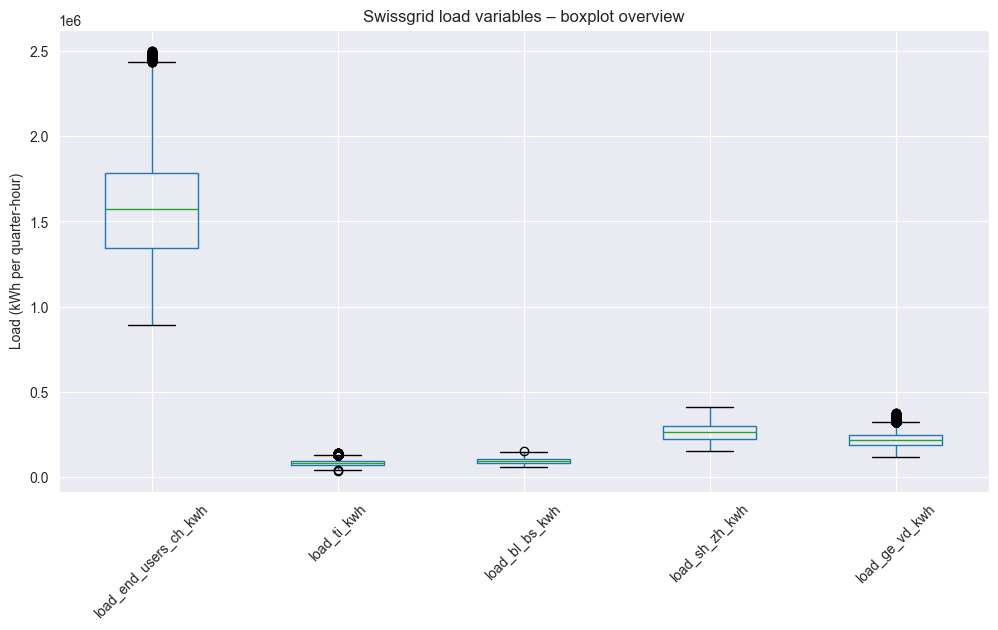

In [30]:
# Quick boxplot inspection of selected load variables

import matplotlib.pyplot as plt

swissgrid_raw_combined[load_cols].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.ylabel("Load (kWh per quarter-hour)")
plt.title("Swissgrid load variables – boxplot overview")
plt.show()

**Range and plausibility findings:**
The selected Swissgrid load variables all fall within plausible operational ranges for quarter-hourly electricity consumption. The Swiss national end-user load ranges from approximately 892,472 to 2,501,306 kWh per quarter-hour, while the regional series range from about 38,049–142,225 kWh for TI, 56,393–150,387 kWh for BL/BS, 150,181–412,175 kWh for SH/ZH, and 119,856–376,405 kWh for GE/VD. These relative magnitudes are consistent with the expected differences between national demand and the selected regional consumption areas.

No negative values and no zero values were detected in any of the selected national or regional load variables. This supports the physical validity of the dataset and indicates that no obvious measurement or import errors remain after standardisation.

The boxplot confirms broad but plausible variation across all series. Apparent statistical outliers are expected in electricity load data due to seasonality, weekday effects, intraday consumption cycles, and weather-related fluctuations. Since all values remain physically plausible, no outlier treatment is done at this stage.

### 3.7 Graphical inspection

To complement the numerical plausibility checks, the selected Swissgrid load variables are inspected visually. Because the raw dataset contains quarter-hourly observations over more than 10 years, direct plotting at full resolution would be too dense to interpret. Therefore, the load variables are temporarily aggregated to daily mean values for graphical inspection.

This visual step helps assess:
- long-term continuity of the series
- recurring seasonal patterns
- relative magnitude differences between national and regional load variables
- unusual spikes, drops, or structural breaks that may indicate data issues

The purpose of this step is exploratory validation rather than formal outlier detection.

In [31]:
# 3.7 Graphical inspection
# Create a daily mean version of the selected load variables for easier visual inspection

load_cols = [
    "load_end_users_ch_kwh",
    "load_ti_kwh",
    "load_bl_bs_kwh",
    "load_sh_zh_kwh",
    "load_ge_vd_kwh"
]

swissgrid_daily_plot = (
    swissgrid_raw_combined
    .assign(date=swissgrid_raw_combined["datetime"].dt.floor("D"))
    .groupby("date")[load_cols]
    .mean()
    .reset_index()
)

swissgrid_daily_plot.head()

,date,load_end_users_ch_kwh,load_ti_kwh,load_bl_bs_kwh,load_sh_zh_kwh,load_ge_vd_kwh
0,2015-01-01,1.623746e+06,87438.507474,92103.499347,260237.020905,225745.218084
1,2015-01-02,1.667422e+06,91841.761188,101057.326646,268470.774115,210283.135708
2,2015-01-03,1.640858e+06,90405.206583,98557.662219,269035.448167,225688.212969
3,2015-01-04,1.541086e+06,83578.929885,91509.481531,255787.670500,234050.793052
4,2015-01-05,1.922213e+06,87754.941292,114176.344208,319670.404583,248443.194490


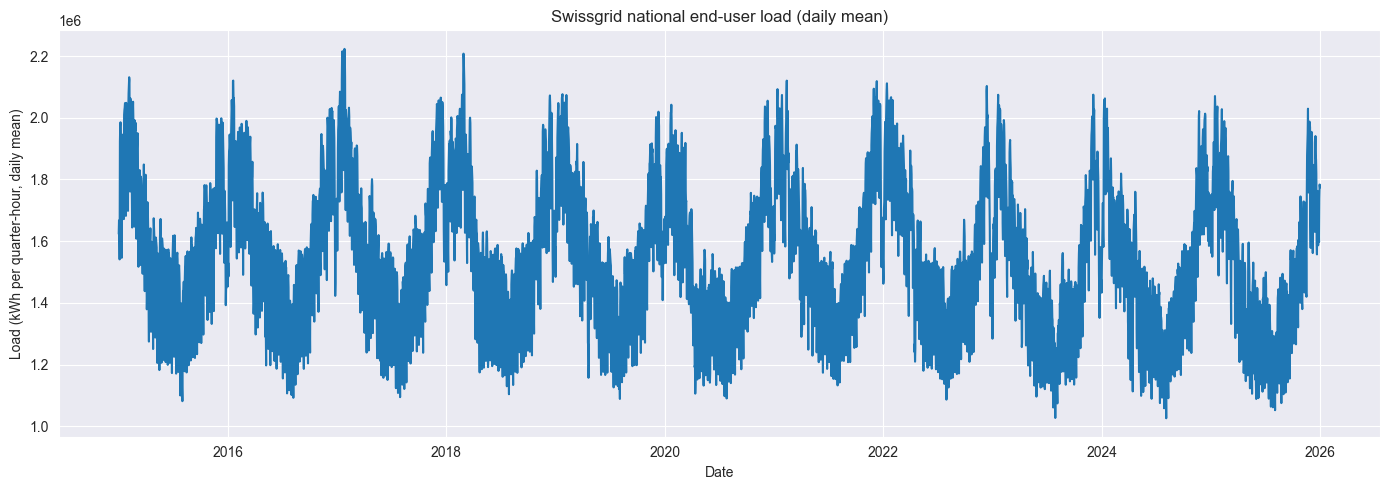

In [32]:
# Plot national daily mean load over time

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(swissgrid_daily_plot["date"], swissgrid_daily_plot["load_end_users_ch_kwh"])
plt.title("Swissgrid national end-user load (daily mean)")
plt.xlabel("Date")
plt.ylabel("Load (kWh per quarter-hour, daily mean)")
plt.tight_layout()
plt.show()

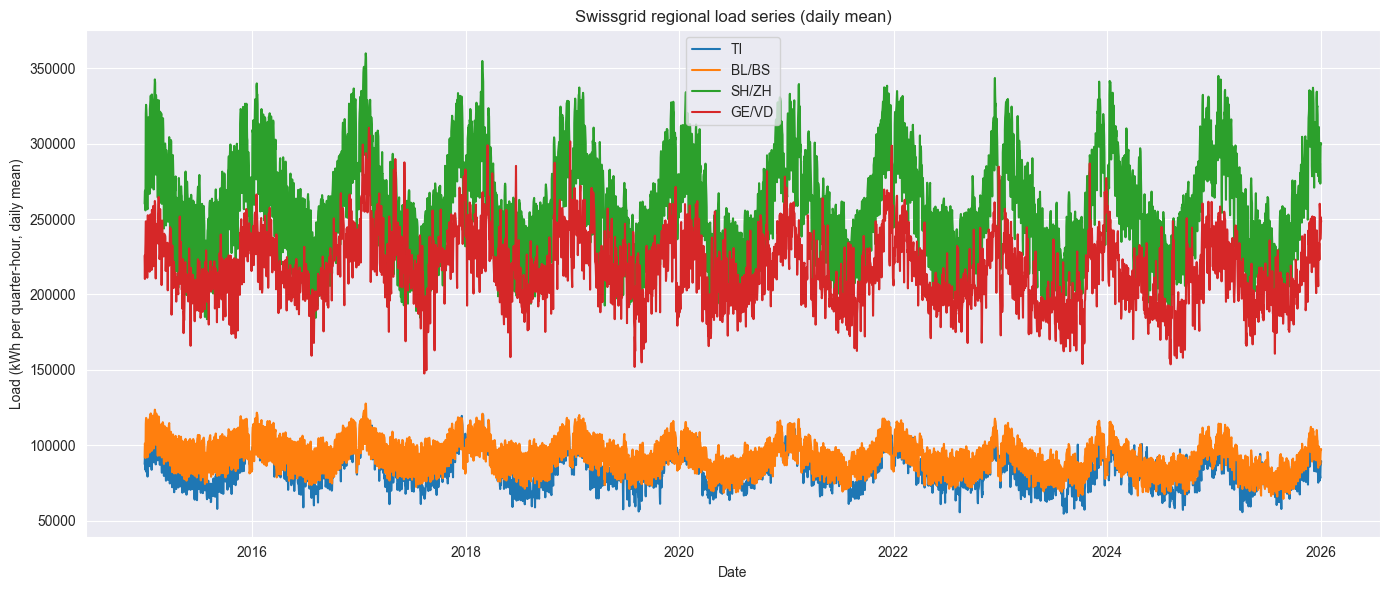

In [33]:
# Plot regional daily mean load over time

plt.figure(figsize=(14, 6))
plt.plot(swissgrid_daily_plot["date"], swissgrid_daily_plot["load_ti_kwh"], label="TI")
plt.plot(swissgrid_daily_plot["date"], swissgrid_daily_plot["load_bl_bs_kwh"], label="BL/BS")
plt.plot(swissgrid_daily_plot["date"], swissgrid_daily_plot["load_sh_zh_kwh"], label="SH/ZH")
plt.plot(swissgrid_daily_plot["date"], swissgrid_daily_plot["load_ge_vd_kwh"], label="GE/VD")

plt.title("Swissgrid regional load series (daily mean)")
plt.xlabel("Date")
plt.ylabel("Load (kWh per quarter-hour, daily mean)")
plt.legend()
plt.tight_layout()
plt.show()

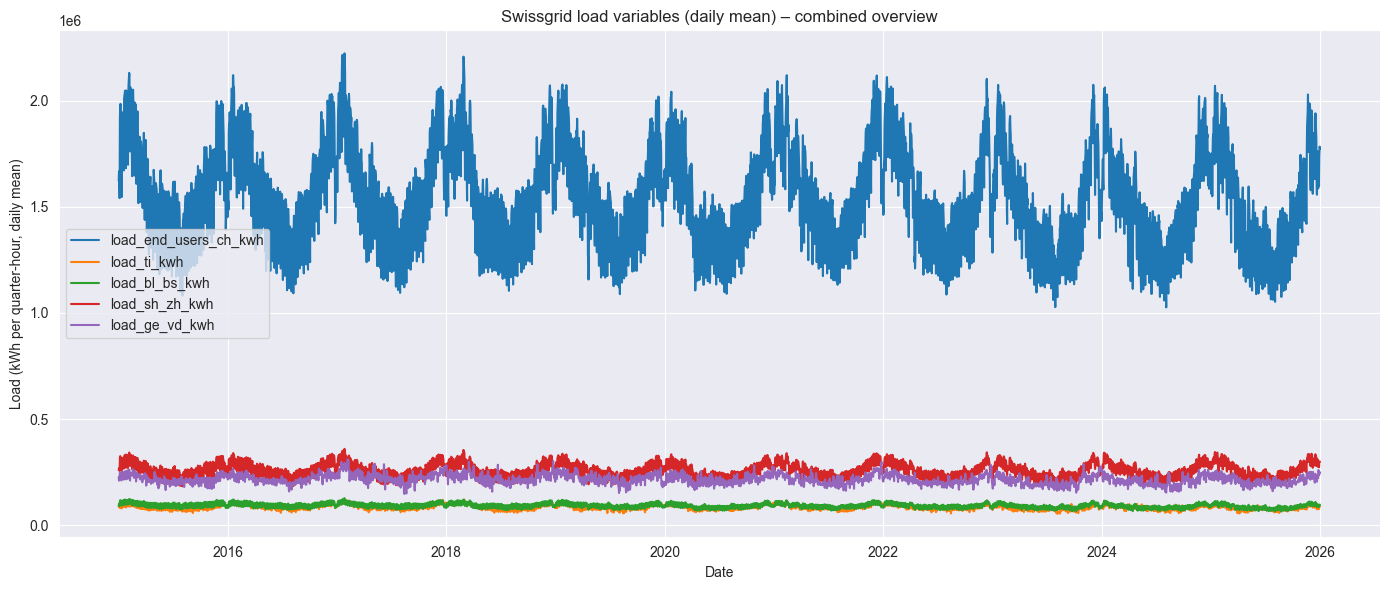

In [34]:
# Optional combined plot for direct comparison

plt.figure(figsize=(14, 6))
for col in load_cols:
    plt.plot(swissgrid_daily_plot["date"], swissgrid_daily_plot[col], label=col)

plt.title("Swissgrid load variables (daily mean) – combined overview")
plt.xlabel("Date")
plt.ylabel("Load (kWh per quarter-hour, daily mean)")
plt.legend()
plt.tight_layout()
plt.show()

**Graphical inspection findings:**
The daily mean plots confirm that the selected Swissgrid load variables are visually consistent and plausible across the full 2015–2025 period. The national end-user load series shows a clear and recurring seasonal pattern, with higher values during winter periods and lower values during warmer months. This behaviour is consistent with expected electricity demand dynamics in Switzerland.

The regional load series for TI, BL/BS, SH/ZH, and GE/VD follow similar long-term temporal patterns at lower magnitudes, which supports the plausibility of the extracted canton-level consumption variables. In particular, SH/ZH and GE/VD exhibit the highest regional demand levels, while TI and BL/BS remain visibly lower, which is coherent with the relative size of these consumption areas.

No obvious structural breaks, prolonged flat segments, or implausible collapses are visible in the plotted series. Short-term peaks and troughs are expected in electricity load data and likely reflect normal variation due to seasonality, holidays, weekday effects, and weather-related demand fluctuations. Overall, the graphical inspection supports the conclusion that the Swissgrid load dataset is suitable for subsequent weekly aggregation and integration with the weather data.

### 3.8 Daily and weekly aggregation for integration

For later integration with the weather data, the Swissgrid load series are aggregated to both **daily** and **weekly** level. This keeps the dataset flexible for subsequent analysis: daily aggregation is useful for descriptive exploration and intermediate checks, while weekly aggregation matches the temporal resolution required for RQ2.

Before aggregation, the selected load variables are converted from **kWh per quarter-hour** into **MW**. This conversion is necessary because the raw Swissgrid values represent energy measured over a 15-minute interval, whereas the research question refers to electricity load in terms of power. For quarter-hourly data, the conversion is:

- `MW = kWh / 250`

After conversion, daily mean and weekly mean load values are calculated for the national and regional series. The resulting datasets are suitable for later integration with daily and weekly weather indicators.

In [35]:
# 3.8 Daily and weekly aggregation for integration
# Convert quarter-hourly kWh values to MW, then aggregate to daily and weekly mean load

load_cols_kwh = [
    "load_end_users_ch_kwh",
    "load_ti_kwh",
    "load_bl_bs_kwh",
    "load_sh_zh_kwh",
    "load_ge_vd_kwh"
]

# Create a working copy
swissgrid_agg_base = swissgrid_raw_combined.copy()

# Convert quarter-hourly kWh values to MW
for col in load_cols_kwh:
    new_col = col.replace("_kwh", "_mw")
    swissgrid_agg_base[new_col] = swissgrid_agg_base[col] / 250

load_cols_mw = [
    "load_end_users_ch_mw",
    "load_ti_mw",
    "load_bl_bs_mw",
    "load_sh_zh_mw",
    "load_ge_vd_mw"
]

# -----------------------------
# Daily aggregation
# -----------------------------
swissgrid_agg_base["date"] = swissgrid_agg_base["datetime"].dt.floor("D")

swissgrid_daily_agg = (
    swissgrid_agg_base
    .groupby("date")[load_cols_mw]
    .mean()
    .reset_index()
)

print("Daily aggregated Swissgrid dataset shape:", swissgrid_daily_agg.shape)
display(swissgrid_daily_agg.head())

# -----------------------------
# Weekly aggregation
# -----------------------------
swissgrid_agg_base["week_start"] = (
    swissgrid_agg_base["datetime"]
    .dt.to_period("W-MON")
    .apply(lambda r: r.start_time)
)

swissgrid_weekly_agg = (
    swissgrid_agg_base
    .groupby("week_start")[load_cols_mw]
    .mean()
    .reset_index()
)

print("Weekly aggregated Swissgrid dataset shape:", swissgrid_weekly_agg.shape)
display(swissgrid_weekly_agg.head())

Daily aggregated Swissgrid dataset shape: (4018, 6)


,date,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw
0,2015-01-01,6494.984874,349.754030,368.413997,1040.948084,902.980872
1,2015-01-02,6669.689356,367.367045,404.229307,1073.883096,841.132543
2,2015-01-03,6563.430637,361.620826,394.230649,1076.141793,902.752852
3,2015-01-04,6164.343765,334.315720,366.037926,1023.150682,936.203172
4,2015-01-05,7688.851055,351.019765,456.705377,1278.681618,993.772778


Weekly aggregated Swissgrid dataset shape: (575, 6)


,week_start,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw
0,2014-12-30,6716.721890,352.821868,397.985058,1098.681332,915.394305
1,2015-01-06,7359.453544,368.795267,439.197849,1205.082946,948.449459
2,2015-01-13,7542.733602,399.597287,445.536427,1220.463913,935.913523
3,2015-01-20,7816.008966,403.774347,457.205968,1263.026155,965.289306
4,2015-01-27,7803.731310,408.515410,454.766960,1250.517165,979.641598


In [36]:
# Inspect date ranges of aggregated datasets

print("Daily dataset range:")
print("Min date:", swissgrid_daily_agg["date"].min())
print("Max date:", swissgrid_daily_agg["date"].max())

print("\nWeekly dataset range:")
print("Min week_start:", swissgrid_weekly_agg["week_start"].min())
print("Max week_start:", swissgrid_weekly_agg["week_start"].max())

Daily dataset range:
Min date: 2015-01-01 00:00:00
Max date: 2025-12-31 00:00:00

Weekly dataset range:
Min week_start: 2014-12-30 00:00:00
Max week_start: 2025-12-30 00:00:00


**Aggregation findings:**
The selected Swissgrid load variables were successfully converted from quarter-hourly energy values in kWh to average load values in MW. Based on these converted series, both a daily and a weekly aggregated dataset were created. The daily dataset contains 4,018 observations covering the full period from 2015-01-01 to 2025-12-31, while the weekly dataset contains 575 observations with week-start dates ranging from 2014-12-30 to 2025-12-30.

The daily aggregated series provide a useful basis for descriptive analysis and intermediate validation. The weekly aggregated dataset is particularly relevant for RQ2, since it matches the intended modelling resolution for explaining weekly electricity load variability using temperature and solar radiation.

The weekly dataset begins on 2014-12-30 because the first calendar week containing observations from January 2015 starts in the previous year. This is a normal consequence of week-based aggregation and does not indicate a data-quality issue. Overall, both aggregated Swissgrid datasets are structurally consistent and ready for later integration with the weather data.

### 3.9 Save cleaned Swissgrid data

After standardisation, validation, and aggregation, the Swissgrid load data is saved in three cleaned output files:

- a cleaned **quarter-hourly** dataset for full-resolution reference,
- a cleaned **daily aggregated** dataset for descriptive analysis and intermediate checks,
- and a cleaned **weekly aggregated** dataset for later integration with weekly weather indicators in RQ2.

Saving all three versions ensures reproducibility and keeps the data preparation flexible for subsequent analysis steps.

In [37]:
# 3.11 Save cleaned Swissgrid data

from pathlib import Path

processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)

# Drop helper column if it exists
if "time_diff" in swissgrid_raw_combined.columns:
    swissgrid_raw_combined = swissgrid_raw_combined.drop(columns=["time_diff"])

# Save cleaned quarter-hourly dataset
swissgrid_raw_combined.to_csv(
    processed_folder / "swissgrid_load_clean_quarter_hourly.csv",
    index=False
)

# Save daily aggregated dataset
swissgrid_daily_agg.to_csv(
    processed_folder / "swissgrid_load_clean_daily.csv",
    index=False
)

# Save weekly aggregated dataset
swissgrid_weekly_agg.to_csv(
    processed_folder / "swissgrid_load_clean_weekly.csv",
    index=False
)

print("Saved files:")
print("-", processed_folder / "swissgrid_load_clean_quarter_hourly.csv")
print("-", processed_folder / "swissgrid_load_clean_daily.csv")
print("-", processed_folder / "swissgrid_load_clean_weekly.csv")

Saved files:
- ..\data\processed\swissgrid_load_clean_quarter_hourly.csv
- ..\data\processed\swissgrid_load_clean_daily.csv
- ..\data\processed\swissgrid_load_clean_weekly.csv


**Summary – Swissgrid Load Cleaning:**
The Swissgrid dataset required moderate structural cleaning: yearly Excel files were standardised and merged, the timestamp column was harmonised across formats, and the selected national and regional load variables were converted to numeric format. No missing values, no negative values, and no implausible zero-load observations were detected; daylight saving time irregularities were identified as expected calendar effects and retained. The cleaned Swissgrid datasets were saved to `data/processed/swissgrid_load_clean_quarter_hourly.csv`, `data/processed/swissgrid_load_clean_daily.csv`, and `data/processed/swissgrid_load_clean_weekly.csv` and are ready for integration with the weather and ENTSO-E datasets.